#Improving Predictions with Data Augmentation

## Part 1 of 3: Looking and Image Augmentations Using TorchVision

- Loading a model from the PyTorch Hub: https://pytorch.org/docs/stable/hub.html

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

torch.manual_seed(123)

## Available ResNet models on TorchHub

In [3]:
entrypoints = torch.hub.list('pytorch/vision', force_reload=True)
for e in entrypoints:
    if "resnet" in e:
        print(e)

Downloading: "https://github.com/pytorch/vision/zipball/main" to /home/zeus/.cache/torch/hub/main.zip
deeplabv3_resnet101
deeplabv3_resnet50
fcn_resnet101
fcn_resnet50
resnet101
resnet152
resnet18
resnet34
resnet50
wide_resnet101_2
wide_resnet50_2


 ## Data (no augmentation yet — just to grab a batch for visualization)

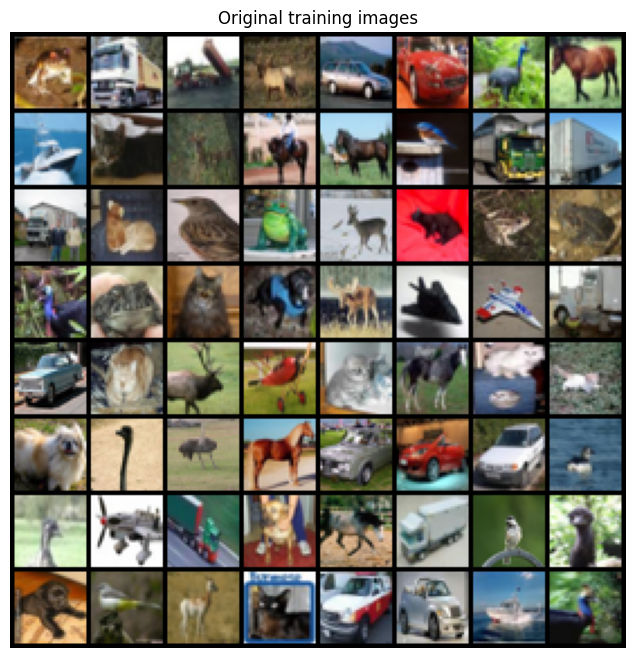

In [11]:
base_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_full = torchvision.datasets.CIFAR10(root="data/", train=True, download=True, transform=base_transform)

images, labels = zip(*[train_full[i] for i in range(64)])
images = torch.stack(images)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Original training images")
plt.imshow(np.transpose(
    torchvision.utils.make_grid(images[:64], padding=2, normalize=True).numpy(),
    (1, 2, 0)
))
plt.show()


## Custom transforms

In [1]:
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomCrop((128, 128)),
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0, 1] -> [-1, 1]
])

test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.CenterCrop((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

NameError: name 'transforms' is not defined

## Visualize train augmentations

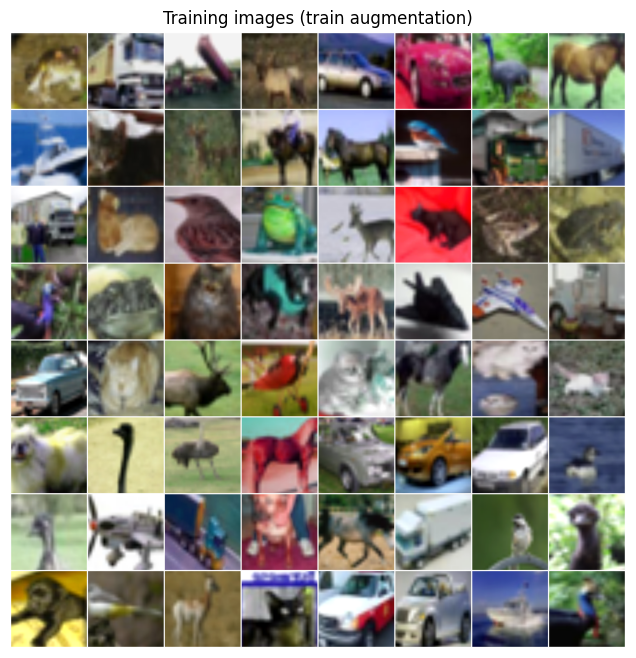

In [13]:
# Re-load with no transform so we can apply manually for visualization
raw_dataset = torchvision.datasets.CIFAR10(root="data/", train=True, download=False, transform=None)
raw_images  = [raw_dataset[i][0] for i in range(64)]  # PIL images

transformed_train = torch.stack([train_transform(img) for img in raw_images])

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images (train augmentation)")
plt.imshow(np.transpose(
    torchvision.utils.make_grid(transformed_train[:64], padding=2, pad_value=1.0, normalize=True).numpy(),
    (1, 2, 0)
))
plt.show()

## Visualize test transforms

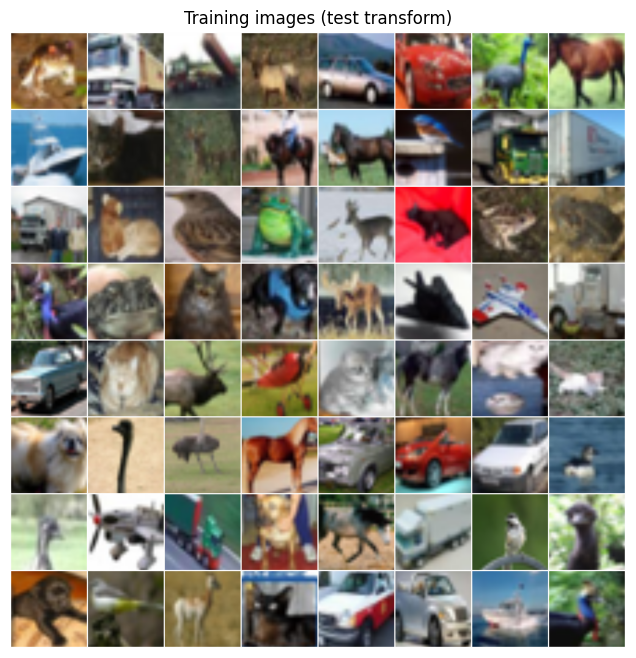

In [14]:
transformed_test = torch.stack([test_transform(img) for img in raw_images])

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images (test transform)")
plt.imshow(np.transpose(
    torchvision.utils.make_grid(transformed_test[:64], padding=2, pad_value=1.0, normalize=True).numpy(),
    (1, 2, 0)
))
plt.show()